#  Datos socio demográficos y de recursos de salud a nivel de condado de EE. UU. (2018-2019)

In [13]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.metrics import r2_score
from pickle import dump

In [14]:
#Carga del conjunto de datos 
url = "https://raw.githubusercontent.com/4GeeksAcademy/regularized-linear-regression-project-tutorial/main/demographic_health_data.csv"
df_raw = pd.read_csv(url)
df_raw = df_raw.drop_duplicates().reset_index(drop=True)

In [15]:
# EDA y División 
target = "Heart disease_number"
 
X = df_raw.select_dtypes(include=[np.number]).drop(columns=[target, 'fips'], errors='ignore').fillna(0)
y = df_raw[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scal = scaler.fit_transform(X_train)
X_test_scal = scaler.transform(X_test)

In [19]:
 
lin_reg = LinearRegression()
lin_reg.fit(X_train_scal, y_train)
r2_base = r2_score(y_test, lin_reg.predict(X_test_scal))

alphas = [0.01, 0.1, 1, 5, 10, 20]
r2_lasso_list = []

for a in alphas:
    lasso_model = Lasso(alpha=a, random_state=42)
    lasso_model.fit(X_train_scal, y_train)
    # Fíjate en los tres paréntesis finales: )))
    r2_lasso_list.append(r2_score(y_test, lasso_model.predict(X_test_scal)))

print("¡Listo! Ya puedes graficar los resultados.")

/home/vscode/.local/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.796e+08, tolerance: 7.097e+07
  model = cd_fast.enet_coordinate_descent(
/home/vscode/.local/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.917e+08, tolerance: 7.097e+07
  model = cd_fast.enet_coordinate_descent(
/home/vscode/.local/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3

¡Listo! Ya puedes graficar los resultados.


/home/vscode/.local/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.235e+08, tolerance: 7.097e+07
  model = cd_fast.enet_coordinate_descent(
/home/vscode/.local/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.845e+08, tolerance: 7.097e+07
  model = cd_fast.enet_coordinate_descent(


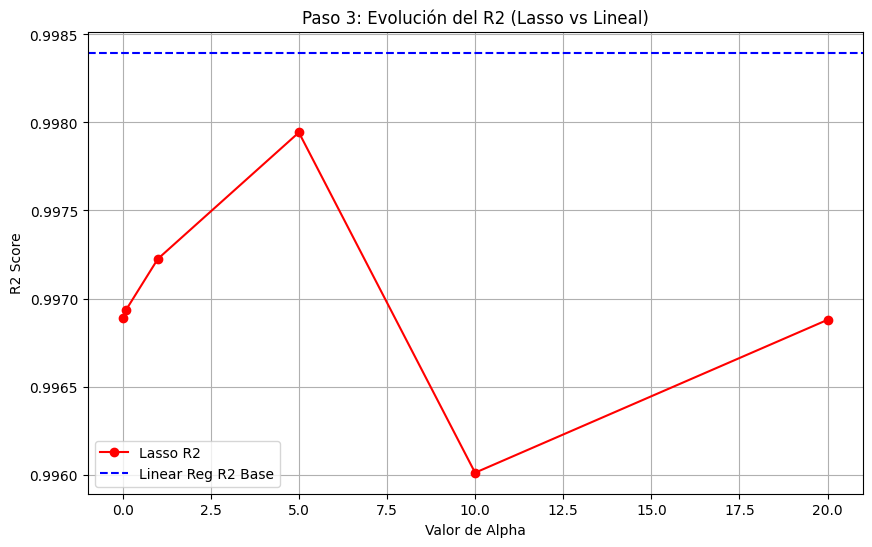

In [20]:
plt.figure(figsize=(10, 6))
plt.plot(alphas, r2_lasso_list, marker='o', color='red', label='Lasso R2')
plt.axhline(y=r2_base, color='blue', linestyle='--', label='Linear Reg R2 Base')
plt.title("Paso 3: Evolución del R2 (Lasso vs Lineal)")
plt.xlabel("Valor de Alpha")
plt.ylabel("R2 Score")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
#optimizacion 
param_grid = {'alpha': [0.001, 0.01, 0.1, 1, 5, 10]}
grid = GridSearchCV(Lasso(random_state=42), param_grid, cv=5)
grid.fit(X_train_scal, y_train)

best_lasso = grid.best_estimator_
print(f"Mejor Alpha encontrado: {grid.best_params_}")
print(f"R2 Final Optimizado: {r2_score(y_test, best_lasso.predict(X_test_scal)):.4f}")

/home/vscode/.local/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.004e+08, tolerance: 6.128e+07
  model = cd_fast.enet_coordinate_descent(
/home/vscode/.local/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.799e+08, tolerance: 6.052e+07
  model = cd_fast.enet_coordinate_descent(
/home/vscode/.local/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2

Mejor Alpha encontrado: {'alpha': 10}
R2 Final Optimizado: 0.9960


/home/vscode/.local/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.235e+08, tolerance: 7.097e+07
  model = cd_fast.enet_coordinate_descent(


In [23]:
os.makedirs("models", exist_ok=True)
dump(best_lasso, open("models/lasso_alpha-optimized.sav", "wb"))